# Chapter 2 - Data and Sampling Distributions

Reproduksi pembelajaran buku **Practical Statistics for Data Scientists: 50+ Essential Concepts Using R and Python**, edisi kedua, Peter Bruce, Andrew Bruce, dan Peter Gedeck (O'Reilly, 2020).

Kode dasar diadaptasi dari [notebook penulis](https://github.com/gedeck/practical-statistics-for-data-scientists/blob/8a6d3bb6468e979c861d4b37215e1413702dfdfa/python/notebooks/Chapter%202%20-%20Data%20and%20sampling%20distributions.ipynb). Copyright (c) 2019 Peter C. Bruce, Andrew Bruce, Peter Gedeck; lisensi GPL-3.0 disertakan pada repo.

**Tujuan:** Mempelajari distribusi sampling, ketidakpastian estimasi, dan distribusi probabilitas melalui resampling serta simulasi. Pembahasan menghubungkan konsep dengan kode dan hasil eksekusi. Dataset tersedia di `data/`, dan output tersimpan agar notebook dapat dibaca langsung. Petunjuk menjalankan ulang serta identitas mahasiswa tercantum pada README.

**Adaptasi:** QQ-plot contoh ekor memakai garis fit, karena data tidak berskala normal standar. Contoh transformasi NFLX dipertahankan dengan batasan interpretasi yang dijelaskan. Seed simulasi dibuat tetap.

## Daftar isi

- [Dasar Sampling dan Ketidakpastian](#dasar-sampling-dan-ketidakpastian)
- [Sampling Distribution of a Statistic](#sampling-distribution-of-a-statistic)
- [The Bootstrap](#the-bootstrap)
- [Confidence Intervals](#confidence-intervals)
- [Normal Distribution](#normal-distribution)
- [Long-Tailed Distributions](#long-tailed-distributions)
- [Binomial Distribution](#binomial-distribution)
- [Poisson and Related Distribution](#poisson-and-related-distribution)
- [Pemeriksaan hasil dan interpretasi](#pemeriksaan-hasil-dan-interpretasi)
- [Random Sampling, Bias, dan Mean Populasi](#random-sampling-bias-dan-mean-populasi)
- [Student's t-Distribution](#students-t-distribution)
- [Chi-Square Distribution dan F-Distribution](#chi-square-distribution-dan-f-distribution)
- [Estimating the Failure Rate](#estimating-the-failure-rate)
- [Ringkasan bab](#ringkasan-bab)

## Dasar Sampling dan Ketidakpastian

**Sampling dan selection bias:** random sampling memilih anggota populasi untuk sampel, sedangkan random assignment membagi perlakuan pada eksperimen. Convenience sampling, survivorship bias, dan nonresponse dapat membuat sampel tidak representatif. Menambah ukuran sampel mengurangi error acak tetapi tidak menghilangkan bias sistematis. Stratified sampling mengambil sampel pada setiap strata untuk menjaga keterwakilan.

**Regression to the mean:** pengamatan ekstrem dapat diikuti nilai lebih dekat rata-rata hanya karena variasi acak. Perubahan ini tidak otomatis membuktikan efek suatu perlakuan.

**Distribusi t:** untuk inferensi mean saat simpangan baku populasi diestimasi, distribusi t memiliki ekor lebih berat daripada normal, terutama pada derajat bebas kecil. **Chi-square** menghubungkan variasi kuadrat dan uji kategori; **F** adalah rasio varians terskala yang dipakai ANOVA. Keduanya dipraktikkan pada Chapter 3.

In [1]:
%matplotlib inline

from pathlib import Path
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.utils import resample

import seaborn as sns
import matplotlib.pylab as plt

In [2]:
# Jalankan dari root repo atau folder notebooks.
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
DATA = ROOT / 'data'
assert DATA.is_dir(), 'Jalankan notebook dari root repo atau folder notebooks.'
np.random.seed(42)


In [3]:
LOANS_INCOME_CSV = DATA / 'loans_income.csv'
SP500_DATA_CSV = DATA / 'sp500_data.csv.gz'

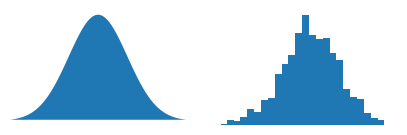

In [4]:
np.random.seed(seed=1)
x = np.linspace(-3, 3, 300)
xsample = stats.norm.rvs(size=1000)

fig, axes = plt.subplots(ncols=2, figsize=(5, 1.5))

ax = axes[0]
ax.fill(x, stats.norm.pdf(x))
ax.set_axis_off()
ax.set_xlim(-3, 3)

ax = axes[1]
ax.hist(xsample, bins=30)
ax.set_axis_off()
ax.set_xlim(-3, 3)
ax.set_position
# plt.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0, hspace=0)

plt.show()

## Sampling Distribution of a Statistic

Distribusi data menggambarkan nilai individual. Distribusi sampling menggambarkan nilai sebuah statistik, misalnya mean, dari pengambilan sampel berulang berukuran sama. Kode membandingkan pendapatan individual dengan 1.000 mean dari sampel berukuran 5 dan 20.

Central limit theorem menyatakan bahwa, di bawah kondisi seperti pengamatan independen dengan varians terbatas, mean terstandarisasi mendekati normal saat ukuran sampel bertambah. Pendapatan individual tidak harus normal. Standard error mean kira-kira $s/\sqrt{n}$, sehingga mean sampel besar biasanya lebih stabil. Sampel besar tidak memperbaiki bias pemilihan.

In [5]:
loans_income = pd.read_csv(LOANS_INCOME_CSV).squeeze('columns')

sample_data = pd.DataFrame({
    'income': loans_income.sample(1000),
    'type': 'Data',
})

sample_mean_05 = pd.DataFrame({
    'income': [loans_income.sample(5).mean() for _ in range(1000)],
    'type': 'Mean of 5',
})

sample_mean_20 = pd.DataFrame({
    'income': [loans_income.sample(20).mean() for _ in range(1000)],
    'type': 'Mean of 20',
})

results = pd.concat([sample_data, sample_mean_05, sample_mean_20])
print(results.head())

         income  type
40292   63000.0  Data
38959   92000.0  Data
17361  134000.0  Data
33996   52000.0  Data
26491   43000.0  Data


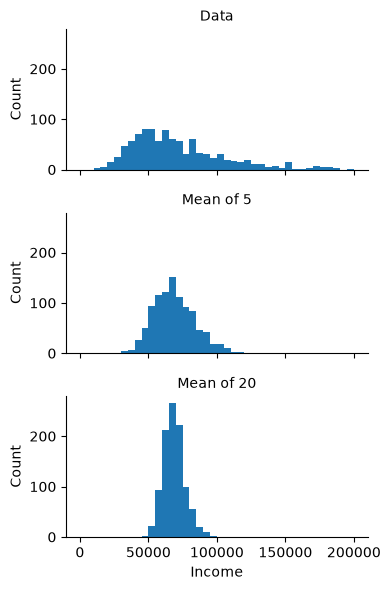

In [6]:
g = sns.FacetGrid(results, col='type', col_wrap=1, 
                  height=2, aspect=2)
g.map(plt.hist, 'income', range=[0, 200000], bins=40)
g.set_axis_labels('Income', 'Count')
g.set_titles('{col_name}')

plt.tight_layout()
plt.show()

## The Bootstrap

Bootstrap mengambil sampel **dengan pengembalian** dari sampel yang tersedia, lalu menghitung statistik pada setiap pengulangan. Ukuran resample biasanya sama dengan ukuran sampel asal. Distribusi median bootstrap memberikan estimasi standard error dan bias relatif terhadap statistik sampel asli.

Ini bukan pengambilan data baru dari populasi. Kualitas bootstrap bergantung pada representativitas sampel dan kesesuaian prosedur dengan struktur data. Data berkelompok atau deret waktu tidak boleh diperlakukan otomatis sebagai pengamatan independen.

In [7]:
results = []
for nrepeat in range(1000):
    sample = resample(loans_income)
    results.append(sample.median())
results = pd.Series(results)
print('Bootstrap Statistics:')
print(f'original: {loans_income.median()}')
print(f'bias: {results.mean() - loans_income.median()}')
print(f'std. error: {results.std()}')

Bootstrap Statistics:
original: 62000.0
bias: -82.09799999999814
std. error: 228.73933106830927


## Confidence Intervals

Percentile bootstrap CI memakai kuantil statistik bootstrap. Kuantil 0,05 dan 0,95 menghasilkan interval 90%; kuantil 0,025 dan 0,975 menghasilkan 95%. Interval 95% umumnya lebih lebar karena menuntut cakupan lebih tinggi.

Interpretasi frequentist: jika prosedur sampling dan pembangunan interval diulang, sekitar 95% interval akan mencakup parameter populasi, ketika asumsi metode terpenuhi. Ini bukan pernyataan bahwa 95% pendapatan individual berada di interval tersebut. Contoh hanya memakai 20 pengamatan sehingga hasilnya sensitif terhadap sampel dan bukan jaminan cakupan tepat.

68760.51844
55734.1


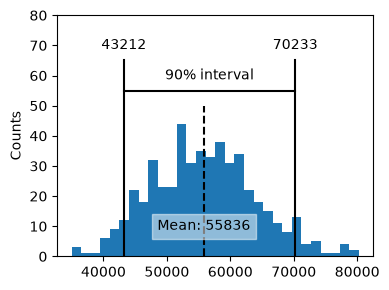

In [8]:
print(loans_income.mean())
np.random.seed(seed=3)  
# create a sample of 20 loan income data
sample20 = resample(loans_income, n_samples=20, replace=False)
print(sample20.mean())
results = []
for nrepeat in range(500):
    sample = resample(sample20)
    results.append(sample.mean())
results = pd.Series(results)

confidence_interval = list(results.quantile([0.05, 0.95]))
ax = results.plot.hist(bins=30, figsize=(4, 3))
ax.plot(confidence_interval, [55, 55], color='black')
for x in confidence_interval:
    ax.plot([x, x], [0, 65], color='black')
    ax.text(x, 70, f'{x:.0f}', 
            horizontalalignment='center', verticalalignment='center')
ax.text(sum(confidence_interval) / 2, 60, '90% interval',
        horizontalalignment='center', verticalalignment='center')

meanIncome = results.mean()
ax.plot([meanIncome, meanIncome], [0, 50], color='black', linestyle='--')
ax.text(meanIncome, 10, f'Mean: {meanIncome:.0f}',
        bbox=dict(facecolor='white', edgecolor='white', alpha=0.5),
        horizontalalignment='center', verticalalignment='center')
ax.set_ylim(0, 80)
ax.set_ylabel('Counts')

plt.tight_layout()
plt.show()

Text(0, 0.5, 'Counts')

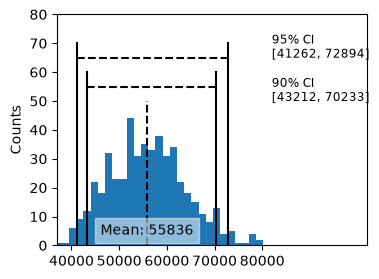

In [9]:
np.random.seed(seed=3)
# create a sample of 20 loan income data
sample20 = resample(loans_income, n_samples=20, replace=False)

results = []
for nrepeat in range(500):
    sample = resample(sample20)
    results.append(sample.mean())
results = pd.Series(results)

confidence_interval = list(results.quantile([0.05, 0.95]))
ax = results.plot.hist(bins=30, figsize=(4, 3), color='C1')
ax.plot(confidence_interval, [55, 55], color='black', linestyle='--')
for x in confidence_interval:
    ax.plot([x, x], [0, 60], color='black')
ax.text(82000, 50, 
        f'90% CI\n[{confidence_interval[0]:.0f}, {confidence_interval[1]:.0f}]',
       fontsize='small')

confidence_interval = list(results.quantile([0.025, 0.975]))
ax = results.plot.hist(bins=30, figsize=(4, 3))
ax.plot(confidence_interval, [65, 65], color='black', linestyle='--')
for x in confidence_interval:
    ax.plot([x, x], [0, 70], color='black')
ax.text(82000, 65, 
        f'95% CI\n[{confidence_interval[0]:.0f}, {confidence_interval[1]:.0f}]',
       fontsize='small')
# ax.text(sum(confidence_interval) / 2, 264, '95 % interval',
#         horizontalalignment='center', verticalalignment='center')

meanIncome = results.mean()
ax.plot([meanIncome, meanIncome], [0, 50], color='black', linestyle='--')
ax.text(meanIncome, 5, f'Mean: {meanIncome:.0f}',
        bbox=dict(facecolor='white', edgecolor='white', alpha=0.5),
        horizontalalignment='center', verticalalignment='center')
ax.set_ylim(0, 80)
ax.set_xlim(37000, 102000)
ax.set_xticks([40000, 50000, 60000, 70000, 80000])
ax.set_ylabel('Counts')

# plt.tight_layout()
# plt.show()

## Normal Distribution

Distribusi normal berbentuk lonceng simetris dan ditentukan mean $\mu$ serta standar deviasi $\sigma$. Standardisasi memakai $z=(x-\mu)/\sigma$. Normal standar mempunyai mean nol dan varians satu. Banyak teknik memakai aproksimasi normal, tetapi data nyata harus diperiksa; jangan menganggap semua data normal.

### Standard Normal and QQ-Plots

QQ-plot memasangkan kuantil sampel dengan kuantil teoritis. Titik mendekati garis lurus menunjukkan kecocokan bentuk distribusi; penyimpangan di ekor mengindikasikan ekor berbeda. Garis identitas cocok sebagai acuan normal standar. Untuk data yang tidak distandardisasi, gunakan garis fit karena lokasi dan skala dapat berbeda.

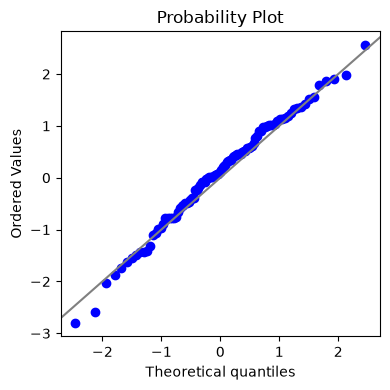

In [10]:
fig, ax = plt.subplots(figsize=(4, 4))

norm_sample = stats.norm.rvs(size=100)
# Use fit=False to disable the default fitting of a line to the sample data (least-squares regression).
stats.probplot(norm_sample, plot=ax, fit=False)
# Plot the diagonal representing the standardized normal distribution.
ax.axline((0, 0), (1, 1), color='gray')

plt.tight_layout()
plt.show()

## Long-Tailed Distributions

Distribusi berekor panjang lebih sering menghasilkan nilai ekstrem daripada normal. Kode sumber memilih perubahan harga NFLX yang positif lalu menghitung selisih lognya. **Ini bukan log-return harga saham:** dataset sumber berisi perubahan harga, sehingga interpretasi finansial sebagai return tidak sah. Contoh direproduksi hanya untuk inspeksi bentuk distribusi; pemilihan nilai positif juga mengubah distribusi dan kedekatan waktu pengamatan. QQ-plot diadaptasi memakai garis fit agar skala tidak tertukar dengan ekor.

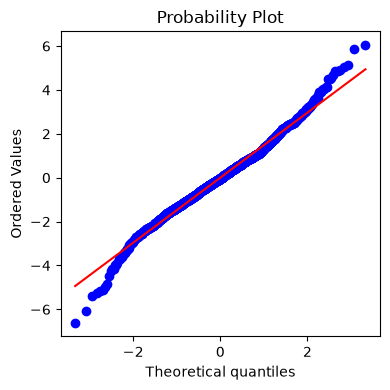

In [11]:
sp500_px = pd.read_csv(SP500_DATA_CSV)

nflx = sp500_px.NFLX
nflx = np.diff(np.log(nflx[nflx>0]))

fig, ax = plt.subplots(figsize=(4, 4))
# Use fit=True to disable the default fitting of a line to the sample data (least-squares regression).
stats.probplot(nflx, plot=ax, fit=True)
# Garis fit menyesuaikan lokasi dan skala sampel.


plt.tight_layout()
plt.show()

## Binomial Distribution

Jika ada $n$ percobaan independen dengan peluang sukses tetap $p$, jumlah sukses mengikuti binomial: $P(X=k)=\binom{n}{k}p^k(1-p)^{n-k}$. `pmf(2, n=5, p=0.1)` adalah peluang tepat dua sukses; `cdf(2, ...)` adalah peluang paling banyak dua. Independen dan peluang tetap merupakan asumsi penting.

In [12]:
print(stats.binom.pmf(2, n=5, p=0.1))

0.07289999999999992


In [13]:
print(stats.binom.cdf(2, n=5, p=0.1))

0.99144


## Poisson and Related Distribution

Poisson memodelkan jumlah kejadian pada suatu interval; eksponensial memodelkan jarak/waktu antar-kejadian pada proses Poisson homogen. Weibull memodelkan waktu kejadian dengan hazard yang dapat berubah. Pemilihan distribusi mengikuti sifat variabel dan asumsi proses, bukan kemiripan histogram saja.

### Poisson Distributions

Poisson mempunyai parameter $\lambda$, dengan mean dan varians sama-sama $\lambda$. Contoh memakai $\lambda=2$ untuk jumlah kejadian per interval. Asumsinya mencakup laju konstan dan kejadian independen. Jika varians data jauh melampaui mean, model Poisson sederhana mungkin tidak memadai.

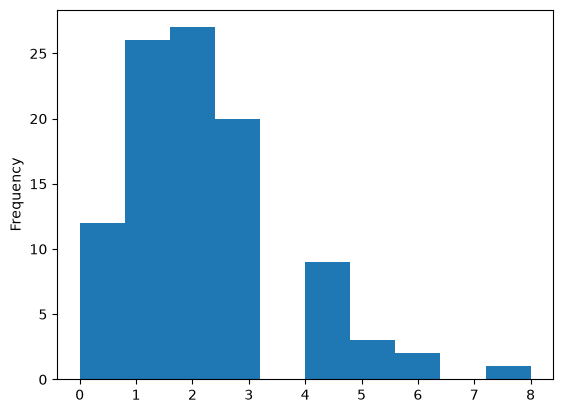

In [14]:
sample = stats.poisson.rvs(2, size=100)

pd.Series(sample).plot.hist()
plt.show()

### Exponential Distribution

Eksponensial dengan laju $\lambda$ mempunyai mean $1/\lambda$ dan sifat memoryless. Pada SciPy, `scale=5` berarti mean lima unit waktu dan laju 0,2 per unit, bukan laju lima. Distribusi hanya memiliki nilai nonnegatif.

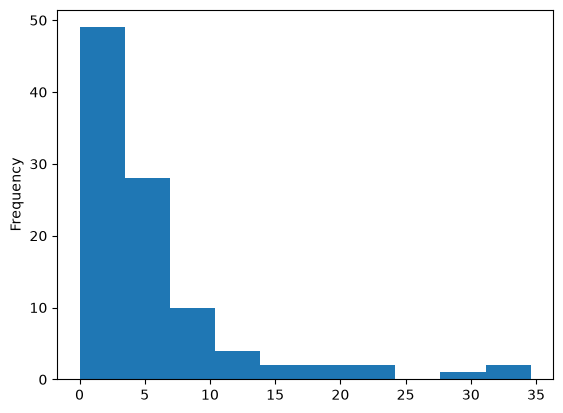

In [15]:
sample = stats.expon.rvs(scale=5, size=100)

pd.Series(sample).plot.hist()
plt.show()

### Weibull Distribution

Weibull memiliki shape $k$ dan scale $\eta$. Hazard konstan ketika $k=1$ (eksponensial), meningkat ketika $k>1$, dan menurun ketika $k<1$. Contoh `shape=1.5, scale=5000` menggambarkan hazard meningkat. Scale tidak sama dengan mean kecuali pada kasus khusus.

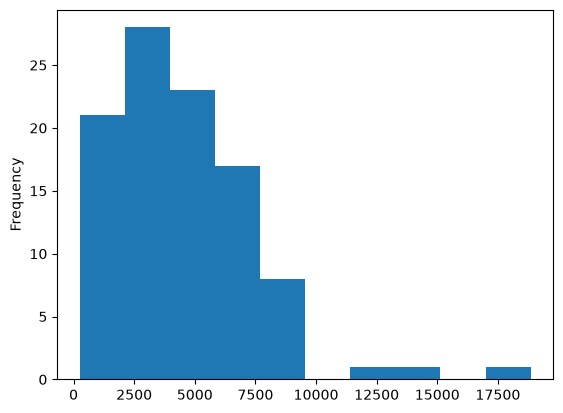

In [16]:
sample = stats.weibull_min.rvs(1.5, scale=5000, size=100)

pd.Series(sample).plot.hist()
plt.show()

## Pemeriksaan hasil dan interpretasi

Sel berikut merangkum hasil utama dan memeriksa konsistensi perhitungan. Assertion mengecek kondisi yang dinyatakan dalam kode; pemeriksaan ini tidak membuktikan seluruh asumsi statistik atau keterwakilan dataset.

In [17]:
print("SD individual, mean-of-5, dan mean-of-20:")
display(pd.concat([sample_data, sample_mean_05, sample_mean_20]).groupby('type')['income'].std())
ci90 = results.quantile([0.05, 0.95]).to_numpy()
ci95 = results.quantile([0.025, 0.975]).to_numpy()
display(pd.DataFrame([ci90, ci95], index=['90%', '95%'], columns=['lower', 'upper']))
assert ci95[0] <= ci90[0] <= ci90[1] <= ci95[1]
print("P(X=2):", stats.binom.pmf(2, n=5, p=0.1))
print("P(X<=2):", stats.binom.cdf(2, n=5, p=0.1))
assert stats.binom.pmf(2, 5, 0.1) <= stats.binom.cdf(2, 5, 0.1)


SD individual, mean-of-5, dan mean-of-20:


type
Data          34440.900351
Mean of 20     7625.452943
Mean of 5     14932.072280
Name: income, dtype: float64

,lower,upper
90%,43212.4500,70233.4400
95%,41262.2225,72893.7725


P(X=2): 0.07289999999999992
P(X<=2): 0.99144


### Interpretasi hasil eksekusi

Pada simulasi ber-seed ini, SD pendapatan individual sekitar **34.441**, SD mean-of-5 sekitar **14.932**, dan SD mean-of-20 sekitar **7.625**. Rata-rata sampel lebih besar lebih stabil walaupun distribusi individu miring.

Bootstrap dari sampel berukuran 20 menghasilkan CI 90% sekitar **[43.212, 70.233]** dan CI 95% sekitar **[41.262, 72.894]**. Interval 95% lebih lebar. Ini interval estimasi mean berdasarkan prosedur bootstrap, bukan rentang yang memuat 95% pendapatan individual.

## Random Sampling, Bias, dan Mean Populasi

Populasi adalah kumpulan yang ingin ditarik kesimpulannya; sampel adalah pengamatan yang tersedia. Mean populasi ditulis $\mu$ dan mean sampel $\bar{x}$. Pada simple random sampling, setiap anggota mempunyai peluang terpilih yang sama. Random sampling tidak identik dengan random assignment perlakuan eksperimen.

Bias adalah penyimpangan sistematis akibat proses pemilihan, pengukuran, atau estimasi. Misalnya survei sukarela cenderung diisi orang yang termotivasi merespons (**self-selection**); survivorship bias mengabaikan unit yang sudah gagal; nonresponse mengabaikan yang tidak menjawab. **Selection bias** juga muncul saat hanya melaporkan percobaan/model dengan hasil paling menarik. Variasi acak berubah antarsampel, sedangkan bias tidak hilang hanya dengan menambah n.

Stratified sampling mengambil sampel dari setiap strata. Jika proporsi pengambilan berbeda dari proporsi populasi, estimasi gabungan memerlukan bobot yang sesuai. Kualitas definisi populasi, pencatatan, dan keterwakilan sering lebih penting daripada jumlah data. Data besar tetap bermanfaat ketika peristiwa atau kombinasi fitur jarang/sparse: jumlah baris besar belum tentu menyediakan banyak informasi relevan untuk semua subkelompok.

### Resampling Versus Bootstrapping

Resampling adalah istilah umum untuk penggunaan ulang data guna menilai variasi atau performa. Bootstrap mengambil dengan pengembalian dari sampel untuk mengestimasi distribusi statistik. Permutation mengacak assignment/label sesuai hipotesis nol; cross-validation memisahkan data untuk menilai generalisasi. Tujuan dan asumsi ketiganya berbeda. Bootstrap biasa tidak memperbaiki sampel yang sejak awal tidak representatif.

## Student's t-Distribution

Jika pengamatan independen berasal dari populasi normal dan standar deviasi populasi tidak diketahui, $T=(\bar{x}-\mu)/(s/\sqrt{n})$ mengikuti distribusi t dengan df $n-1$. Ekor t lebih berat daripada normal karena estimasi s menambah ketidakpastian. Saat df bertambah, distribusi t mendekati normal standar. Distribusi t adalah distribusi **statistik terstandarisasi**, bukan klaim bahwa semua data mentah atau semua mean sampel mengikuti t secara tepat.

Confidence interval mean adalah $\bar{x}\pm t_{1-\alpha/2,n-1}s/\sqrt{n}$. Hasil tepat bergantung pada asumsi normal; pada n besar sering dipakai sebagai aproksimasi. Sampel kecil dengan skew kuat atau outlier dapat membuat interval tidak andal. Standard deviation menggambarkan sebaran individu; standard error menggambarkan ketidakpastian statistik. Contoh berikut memakai data sintetis ber-seed dengan model normal yang diketahui, bukan mengganti CI bootstrap pendapatan sebelumnya.

## Chi-Square Distribution dan F-Distribution

Jika $Z_j$ normal standar independen, $\sum_{j=1}^{k} Z_j^2$ mengikuti chi-square dengan df k. Nilainya nonnegatif, mean k dan varians 2k. Salah satu penggunaan ialah statistik penyimpangan frekuensi kategori dari nilai harapan; aproksimasinya memerlukan hitungan harapan memadai. Pada populasi normal, $(n-1)s^2/\sigma^2$ juga mempunyai distribusi chi-square dengan df n-1.

Untuk dua variabel chi-square independen U dan V, $F=(U/d_1)/(V/d_2)$ mengikuti distribusi F dengan dua derajat bebas $d_1,d_2$. Statistik ANOVA membandingkan mean square antar-kelompok dan dalam-kelompok. Karena distribusi tidak simetris, p-value untuk F besar memakai ekor kanan dan tidak dibagi dua. Distribusi chi-square dan F bukan distribusi data kategori/nilai individual: keduanya menjadi acuan statistik uji. Di SciPy, `sf(x)` langsung menghitung peluang ekor kanan; `ppf(q)` mencari kuantil q.

In [18]:
distribution_rng = np.random.default_rng(42)
t_example = distribution_rng.normal(loc=50, scale=10, size=20)
t_example_se = t_example.std(ddof=1) / np.sqrt(len(t_example))
t_example_interval = stats.t.interval(0.95, df=len(t_example)-1,
                                     loc=t_example.mean(), scale=t_example_se)
display(pd.Series({'mean_sintetis': t_example.mean(), 'standard_error': t_example_se,
                   'CI95_lower': t_example_interval[0], 'CI95_upper': t_example_interval[1]}))
display(pd.DataFrame({'distribusi': ['normal', 't df=5', 't df=30'],
                      'kuantil_97.5%': [stats.norm.ppf(0.975), stats.t.ppf(0.975, 5),
                                        stats.t.ppf(0.975, 30)]}))
print('Chi-square df=2, P(X>=5):', stats.chi2.sf(5, df=2))
print('F df=(3,16), P(F>=3):', stats.f.sf(3, dfn=3, dfd=16))
assert stats.t.ppf(0.975, 5) > stats.t.ppf(0.975, 30) > stats.norm.ppf(0.975)
assert t_example_interval[0] < t_example.mean() < t_example_interval[1]
print('Interpretasi: df kecil memiliki nilai kritis lebih besar, untuk SE sama interval lebih lebar.')

mean_sintetis     49.670679
standard_error     1.945777
CI95_lower        45.598122
CI95_upper        53.743237
dtype: float64

,distribusi,kuantil_97.5%
0,normal,1.959964
1,t df=5,2.570582
2,t df=30,2.042272


Chi-square df=2, P(X>=5): 0.0820849986238988
F df=(3,16), P(F>=3): 0.06154467935518723
Interpretasi: df kecil memiliki nilai kritis lebih besar, untuk SE sama interval lebih lebar.


## Estimating the Failure Rate

Laju kejadian/failure $\lambda$ menyatakan jumlah kejadian per unit exposure, bukan probabilitas gagal pada sebuah saat tanpa satuan. Untuk proses Poisson dengan laju konstan, estimasi likelihood maksimum adalah $\hat\lambda=k/T$, dengan k jumlah kejadian dan T total waktu exposure. Pada model eksponensial tanpa censoring, ini sama dengan $1/\bar{t}$ untuk waktu antar-kejadian atau lifetime independen.

Laju konstan berarti survival $S(t)=e^{-\lambda t}$ dan peluang gagal sebelum t adalah $1-S(t)$. Contoh tambahan: 4 kegagalan selama total 200 device-hours memberi estimasi 0,02 per device-hour. Total exposure menjumlahkan waktu tiap perangkat yang diamati, bukan hanya waktu kalender.

Jika tidak ada kejadian, estimasi titik nol **tidak membuktikan risiko nol**. Di bawah model Poisson, batas atas satu arah 95% adalah $-\log(0.05)/T$, diperoleh dari peluang mengamati nol kejadian $e^{-\lambda T}$. Ketika data terbatas, estimasi harus disertai ketidakpastian. Laju yang berubah menurut umur/waktu memerlukan segmentasi atau model lain, misalnya Weibull. Censoring dan dependensi perangkat harus dipertimbangkan sesuai desain.

**Parameter SciPy:** untuk laju 0,2, gunakan `stats.expon.rvs(scale=1/0.2, ...)`. Argumen posisi pertama pada SciPy adalah `loc`, bukan rate. Notebook ini mempertahankan `scale=5` yang benar pada kode penulis; contoh posisi `0.2` yang tercetak pada buku tidak dipakai sebagai rate.

In [19]:
failure_events, total_device_hours = 4, 200.0
estimated_failure_rate = failure_events / total_device_hours
failure_probability_10h = stats.expon.cdf(10, scale=1 / estimated_failure_rate)
zero_event_upper95 = -np.log(0.05) / total_device_hours
display(pd.Series({'rate_per_device_hour': estimated_failure_rate,
                   'model_probability_failure_before_10h': failure_probability_10h,
                   'upper95_rate_if_zero_events_in_200h': zero_event_upper95}))
assert np.isclose(failure_probability_10h, 1 - np.exp(-estimated_failure_rate * 10))
assert zero_event_upper95 > 0
print('Interpretasi: laju 0,02/jam berbeda dari peluang sekitar 0,181 dalam 10 jam.')

rate_per_device_hour                    0.020000
model_probability_failure_before_10h    0.181269
upper95_rate_if_zero_events_in_200h     0.014979
dtype: float64

Interpretasi: laju 0,02/jam berbeda dari peluang sekitar 0,181 dalam 10 jam.


## Ringkasan bab

Distribusi nilai individual berbeda dari distribusi statistik sampel. Pada simulasi pendapatan, simpangan baku nilai individual sekitar **34.441**, sedangkan simpangan baku mean sampel berukuran 5 dan 20 sekitar **14.932** dan **7.625**. Mean-of-20 lebih stabil karena rata-rata menggabungkan lebih banyak pengamatan. SD menggambarkan sebaran pendapatan individual, sementara standard error menggambarkan variasi estimasi mean dari pengambilan sampel berulang.

Interval bootstrap **90% sekitar [43.212, 70.233]** berada di dalam interval **95% sekitar [41.262, 72.894]**. Cakupan yang lebih tinggi membutuhkan interval lebih lebar pada prosedur dan data yang sama. Bootstrap memakai sampel yang tersedia untuk mengestimasi ketidakpastian; sampel yang bias tetap menghasilkan inferensi yang dapat bias meskipun resampling dilakukan berkali-kali.

Pada distribusi eksponensial, `scale=5` berarti waktu tunggu rata-rata 5 satuan, setara dengan rate 0,2 per satuan waktu. Rate dan probabilitas bukan besaran yang sama: dalam ilustrasi 4 kegagalan selama 200 jam, rate estimasinya **0,02 per jam**, sedangkan peluang setidaknya satu kegagalan selama 10 jam sekitar **18,13%** dengan asumsi proses Poisson ber-rate tetap.

Nol kegagalan yang diamati tidak membuktikan risiko nol. Pada ilustrasi nol kejadian selama 200 jam, batas atas satu sisi 95% untuk rate masih sekitar **0,01498 per jam**. Distribusi t, chi-square, dan F menyediakan acuan bagi statistik inferensi dengan asumsi masing-masing. Pemilihan distribusi dan penafsiran interval harus mengikuti proses data, satuan, serta parameter yang digunakan.